# Part 1 — Steps 6 & 7: Algorithm Selection & Training
**Problem type:** Multi-output Regression (predict 3 continuous targets simultaneously)

**Algorithms compared:**
| # | Algorithm | Type | Rationale |
|---|---|---|---|
| 1 | Random Forest Regressor | ML (ensemble) | Handles non-linearity, robust, feature importance |
| 2 | Multi-output SVR | ML (kernel) | Good for small datasets, handles high-dim well |
| 3 | MLP Neural Network | DL (dense) | Can learn complex feature interactions |

Run after `agriculture_splitting.ipynb`.

In [1]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, time

from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm            import SVR
from sklearn.multioutput    import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics        import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Cell 2 : Load pre-saved splits ────────────────────────────────────────────
with open('splits/split_data.pkl', 'rb') as f:
    s = pickle.load(f)

X_train = s['X_train'];  y_train = s['y_train']
X_val   = s['X_val'];    y_val   = s['y_val']
X_test  = s['X_test'];   y_test  = s['y_test']
TARGET_COLS  = s['target_cols']
FEATURE_COLS = s['feature_cols']

print(f'Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}')

Train : (1392, 17)  Val : (298, 17)  Test : (299, 17)


---
## Algorithm 1 — Random Forest Regressor (ML)

In [3]:
# ── Cell 3 : Train RandomForestRegressor ─────────────────────────────────────
#
# RandomForestRegressor natively supports multi-output regression.
# n_estimators=200 for a good bias-variance tradeoff at this dataset size.
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f'RandomForest trained in {time.time()-t0:.1f}s')

y_pred_rf_val  = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

r2_rf_val  = r2_score(y_val,  y_pred_rf_val,  multioutput='uniform_average')
r2_rf_test = r2_score(y_test, y_pred_rf_test, multioutput='uniform_average')

print(f'RandomForest — Val R²={r2_rf_val:.4f}  Test R²={r2_rf_test:.4f}')

RandomForest trained in 0.3s
RandomForest — Val R²=0.6109  Test R²=0.6329


---
## Algorithm 2 — Multi-output SVR (ML)

In [4]:
# ── Cell 4 : Train MultiOutputRegressor with SVR ──────────────────────────────
#
# SVR does not natively support multi-output; we wrap it with MultiOutputRegressor,
# which fits one SVR per target (3 SVRs total).
# RBF kernel captures non-linear relationships. C=10, epsilon=0.1 are common defaults.
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()
svr = MultiOutputRegressor(
    SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    n_jobs=-1
)
svr.fit(X_train, y_train)
print(f'SVR trained in {time.time()-t0:.1f}s')

y_pred_svr_val  = svr.predict(X_val)
y_pred_svr_test = svr.predict(X_test)

r2_svr_val  = r2_score(y_val,  y_pred_svr_val,  multioutput='uniform_average')
r2_svr_test = r2_score(y_test, y_pred_svr_test, multioutput='uniform_average')

print(f'SVR — Val R²={r2_svr_val:.4f}  Test R²={r2_svr_test:.4f}')

SVR trained in 2.7s
SVR — Val R²=0.6667  Test R²=0.7217


---
## Algorithm 3 — MLP Neural Network (Deep Learning)

In [5]:
# ── Cell 5 : Train MLPRegressor (Deep Learning) ───────────────────────────────
#
# Architecture: Input → 128 → 64 → 32 → 3 outputs
# Activation: ReLU, Optimizer: Adam, max_iter=500 epochs.
# MLPRegressor natively handles multi-output regression.
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,             # L2 regularisation
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
mlp.fit(X_train, y_train)
print(f'MLP trained in {time.time()-t0:.1f}s  (stopped at iter {mlp.n_iter_})')

y_pred_mlp_val  = mlp.predict(X_val)
y_pred_mlp_test = mlp.predict(X_test)

r2_mlp_val  = r2_score(y_val,  y_pred_mlp_val,  multioutput='uniform_average')
r2_mlp_test = r2_score(y_test, y_pred_mlp_test, multioutput='uniform_average')

print(f'MLP — Val R²={r2_mlp_val:.4f}  Test R²={r2_mlp_test:.4f}')

MLP trained in 2.3s  (stopped at iter 188)
MLP — Val R²=0.6842  Test R²=0.7476


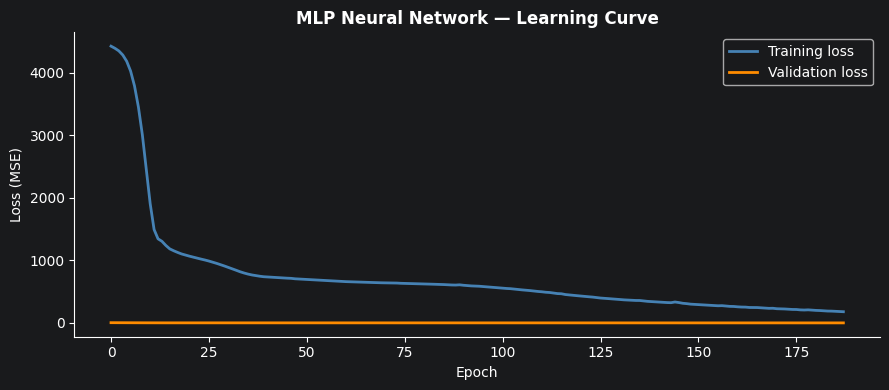

In [6]:
# ── Cell 6 : MLP learning curve ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_curve_,       label='Training loss',   color='steelblue',  linewidth=2)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    val_loss = [-v for v in mlp.validation_scores_]
    ax.plot(val_loss, label='Validation loss', color='darkorange', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('MLP Neural Network — Learning Curve', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('training_mlp_curve.png', dpi=120)
plt.show()

In [7]:
# ── Cell 7 : Algorithm comparison table ──────────────────────────────────────

def eval_model(model, X_v, y_v, X_te, y_te):
    yp_v  = model.predict(X_v)
    yp_te = model.predict(X_te)
    return {
        'Val R2'   : round(r2_score(y_v,  yp_v,  multioutput='uniform_average'), 4),
        'Test R2'  : round(r2_score(y_te, yp_te, multioutput='uniform_average'), 4),
        'Val RMSE' : round(np.sqrt(mean_squared_error(y_v,  yp_v)),  3),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_te, yp_te)), 3),
        'Val MAE'  : round(mean_absolute_error(y_v,  yp_v),  3),
        'Test MAE' : round(mean_absolute_error(y_te, yp_te), 3),
    }

results = {
    'RandomForest' : eval_model(rf,  X_val, y_val, X_test, y_test),
    'SVR'          : eval_model(svr, X_val, y_val, X_test, y_test),
    'MLP'          : eval_model(mlp, X_val, y_val, X_test, y_test),
}

df_results = pd.DataFrame(results).T
print('\n=== Algorithm Comparison ===')
print(df_results.to_string())
best_model_name = df_results['Test R2'].idxmax()
print(f'\nBest model by Test R² : {best_model_name}')


=== Algorithm Comparison ===
              Val R2  Test R2  Val RMSE  Test RMSE  Val MAE  Test MAE
RandomForest  0.6109   0.6329    63.090     41.479   18.632    17.498
SVR           0.6667   0.7217    77.451     49.493   16.101    15.241
MLP           0.6842   0.7476    72.339     44.254   15.913    14.038

Best model by Test R² : MLP


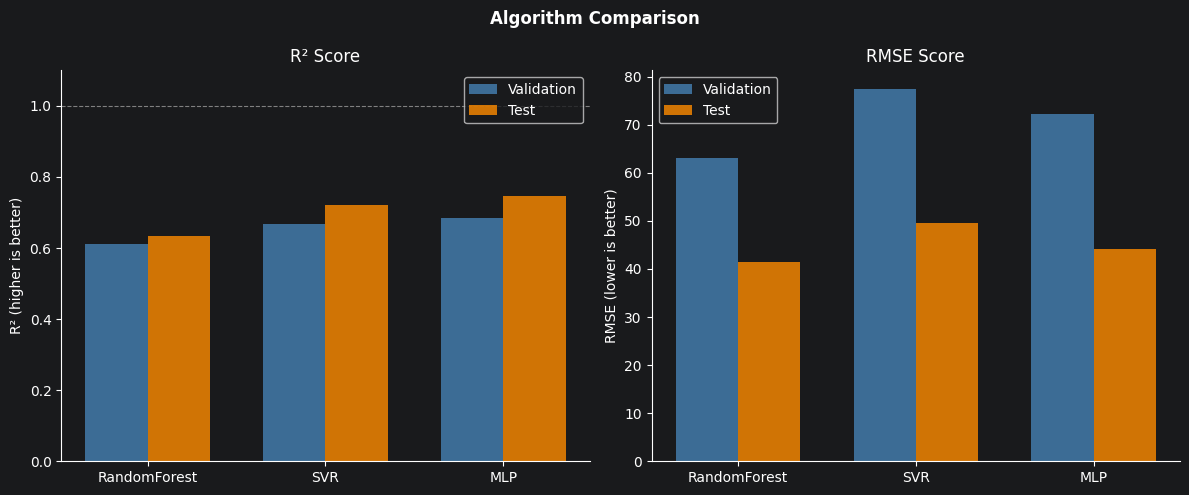

In [8]:
# ── Cell 8 : Visualise comparison ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Algorithm Comparison', fontsize=12, fontweight='bold')

models  = list(results.keys())
colors  = ['steelblue', 'darkorange', 'seagreen']
x       = np.arange(len(models))
w       = 0.35

# R² bar chart
ax = axes[0]
ax.bar(x - w/2, [results[m]['Val R2']  for m in models], w, label='Validation', color='steelblue', alpha=0.8)
ax.bar(x + w/2, [results[m]['Test R2'] for m in models], w, label='Test',       color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('R² (higher is better)')
ax.set_title('R² Score')
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMSE bar chart
ax = axes[1]
ax.bar(x - w/2, [results[m]['Val RMSE']  for m in models], w, label='Validation', color='steelblue', alpha=0.8)
ax.bar(x + w/2, [results[m]['Test RMSE'] for m in models], w, label='Test',       color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('RMSE Score')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=120)
plt.show()

In [9]:
# ── Cell 9 : Save all trained models ─────────────────────────────────────────
os.makedirs('models', exist_ok=True)

with open('models/rf_model.pkl',  'wb') as f: pickle.dump(rf,  f)
with open('models/svr_model.pkl', 'wb') as f: pickle.dump(svr, f)
with open('models/mlp_model.pkl', 'wb') as f: pickle.dump(mlp, f)
with open('models/results.pkl',   'wb') as f: pickle.dump(results, f)

print('Saved: models/rf_model.pkl, svr_model.pkl, mlp_model.pkl')
print(f'Best model: {best_model_name}')

Saved: models/rf_model.pkl, svr_model.pkl, mlp_model.pkl
Best model: MLP
